In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df = pd.read_csv('Churn.csv')

In [82]:
df.head(-5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9990,9991,15798964,Nkemakonam,714,Germany,Male,33,3,35016.60,1,1,0,53667.08,0
9991,9992,15769959,Ajuluchukwu,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9992,9993,15657105,Chukwualuka,726,Spain,Male,36,2,0.00,1,1,0,195192.40,0
9993,9994,15569266,Rahman,644,France,Male,28,7,155060.41,1,1,0,29179.52,0


In [41]:
df.shape

(10000, 14)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [43]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [44]:
df.isnull()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [45]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [46]:
churned = df['Exited'].sum()
churned

np.int64(2037)

In [47]:
total_custom = len(df)

In [48]:
stayed = total_custom - churned
churn_rate = (churned/total_custom) * 100
print(f'churn rate: {churn_rate:.2f}%')

churn rate: 20.37%


In [49]:
#visuvalization on churn by what the customers are leaving
geo_churn = df.groupby('Geography')['Exited'].mean()*100
geo_churn

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

<Axes: xlabel='Geography'>

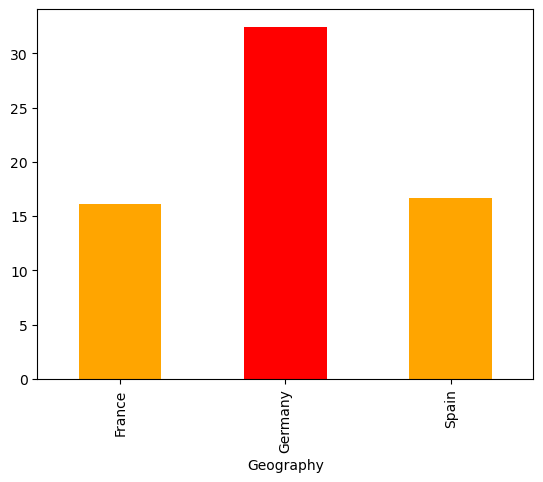

In [50]:
#churn by geography
colors = ['red' if rate > 20 else 'orange' if rate > 15 else 'green' for rate in geo_churn]
geo_churn.plot(kind='bar', color = colors)

In [51]:
#churn by gender
gen_churn = df.groupby('Gender')['Exited'].mean()*100
gen_churn

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

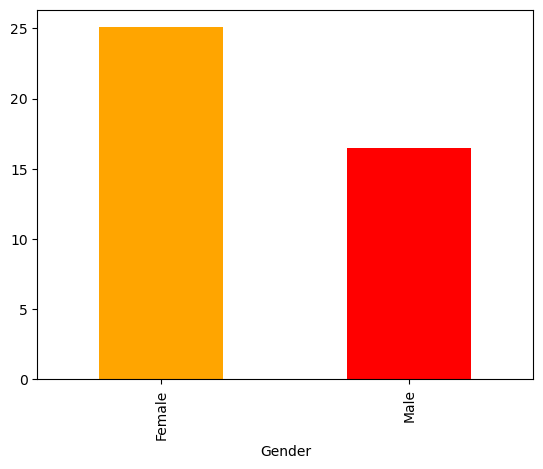

In [52]:
gen_churn.plot(kind = 'bar', color = colors)
plt.show()

In [53]:
#we have to still visuvalize
#we have to find still outliers

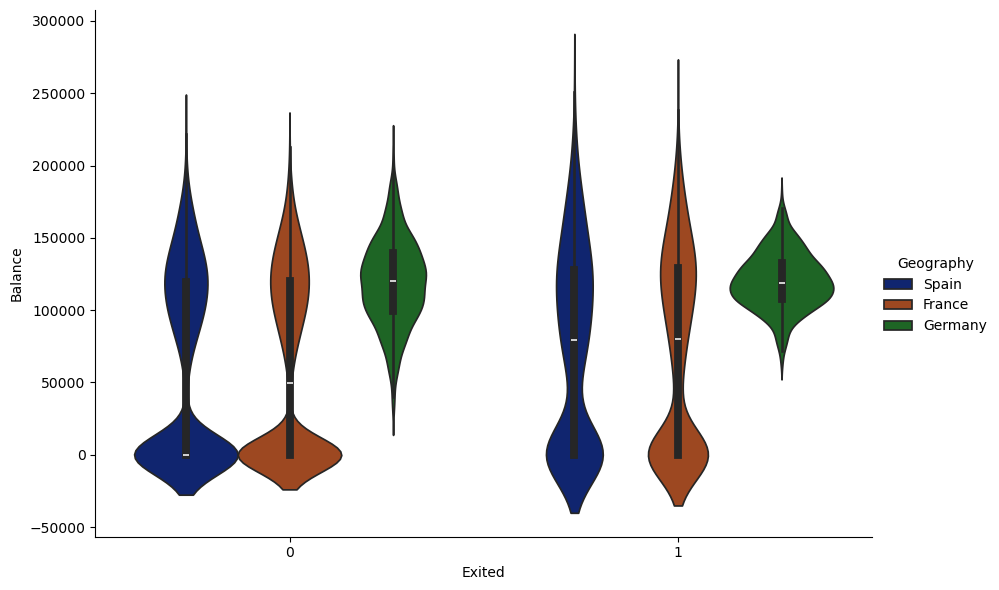

In [54]:
sns.catplot(data=df, 
            x='Exited', 
            y='Balance', 
            kind='violin', 
            hue='Geography',
            palette='dark',
            height=6,
            aspect=1.5)

In [83]:
data = df.copy()

In [84]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Encoder for gender and Geography

In [73]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [85]:
gender_enc = LabelEncoder()
geo_enc = LabelEncoder()

In [88]:
gender_enc.fit(data['Gender'])
geo_enc.fit(data['Geography'])

LabelEncoder()

In [89]:
data['Gender'] = gender_enc.transform(data['Gender'])
data['Geography'] = geo_enc.transform(data['Geography'])

In [78]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0


# split the data

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
x = data.drop(['RowNumber','CustomerId','Surname','Exited'], axis =1)
y = data['Exited']

In [92]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [93]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [94]:
x_train , x_test , y_train ,y_test = train_test_split(x,y,test_size = 0.2)

In [95]:
x_train.shape , y_train.shape , x_test.shape , y_test.shape

((8000, 10), (8000,), (2000, 10), (2000,))

# Scaling the data

In [96]:
x_train2 = x_train.copy()
x_test2 = x_test.copy()

In [97]:
from sklearn.preprocessing import StandardScaler

In [98]:
scaler = StandardScaler()

In [99]:
x_train_scaled = scaler.fit_transform(x_train2)
x_test_scaled = scaler.transform(x_test2)

# Logistic Regression 

In [100]:
from sklearn.linear_model import LogisticRegression

In [101]:
model = LogisticRegression()

In [102]:
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [137]:
y_hat = model.predict(x_test_scaled)

In [138]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score

In [140]:
Accuracy = accuracy_score(y_test, y_hat)
cm = confusion_matrix(y_test, y_hat)
recall = recall_score(y_test, y_hat)
pre = precision_score(y_test, y_hat)


In [141]:
print(classification_report(y_test , y_hat))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1594
           1       0.38      0.70      0.49       406

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.64      2000
weighted avg       0.80      0.71      0.73      2000



In [136]:
Accuracy , cm , recall, pre

(0.702125,
 array([[4509, 1860],
        [ 523, 1108]]),
 0.6793378295524218,
 0.37331536388140163)

# Logistic Regression with Smote

In [108]:
# here the model is highly imbalanced so that we gone balance it  by sampling techinque , we use smote sampling

from imblearn.over_sampling import SMOTE

In [109]:
smote = SMOTE(random_state = 42)

In [110]:
x_train_balanced, y_train_balanced = smote.fit_resample(x_train_scaled,y_train)

In [111]:
model.fit(x_train_balanced,y_train_balanced)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [112]:
y_pred_balance =model.predict(x_test_scaled)

In [113]:
Accuracy = accuracy_score(y_test, y_pred_balance)
cm = confusion_matrix(y_test, y_pred_balance )
recall = recall_score(y_test, y_pred_balance )
pre = precision_score(y_test, y_pred_balance )


In [114]:
print(classification_report(y_test , y_pred_balance))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1594
           1       0.38      0.70      0.49       406

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.64      2000
weighted avg       0.80      0.71      0.73      2000



In [115]:
Accuracy , cm , recall, pre

(0.7075,
 array([[1132,  462],
        [ 123,  283]]),
 0.6970443349753694,
 0.37986577181208053)

# XGBOOST

In [116]:
#now we are going to wrok with the xgboost this may perform well than logistic regression and improves more recall
# we use normal non-balnced data for xgboost 
# we use our scaled data as iwas already prepared, with out scaled also it is fine

In [117]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [118]:
from xgboost import XGBClassifier

In [119]:
#now we have to calculate imbalnce ratio and say to model that the churn is important
scale_pos_weight = len(y_train[y_train==0])/len(y_train[y_train ==1])


In [120]:
xgb_model = XGBClassifier(scale_pos_weight = scale_pos_weight, n_estimators = 100, max_depth = 6,learning_rate = 0.1, random_state = 42,use_label_encoder=False,            # Avoid warning
    eval_metric='logloss' , objective='binary:logistic')

In [121]:
xgb_model.fit(x_train_scaled , y_train)

C:\Users\Lenovo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:30:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [122]:
y_hat_pred = xgb_model.predict(x_test_scaled)

In [123]:
Accuracy = accuracy_score(y_test, y_hat_pred)
cm = confusion_matrix(y_test, y_hat_pred )
recall = recall_score(y_test, y_hat_pred )
pre = precision_score(y_test, y_hat_pred )

In [124]:
print(classification_report(y_test , y_hat_pred))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88      1594
           1       0.54      0.75      0.62       406

    accuracy                           0.82      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.82      0.83      2000



In [125]:
Accuracy , cm , recall, pre

(0.818,
 array([[1333,  261],
        [ 103,  303]]),
 0.7463054187192119,
 0.5372340425531915)

In [127]:
import joblib

combined = {
    'model' : xgb_model,
    'scaler' : scaler,
    'gender_encoder':gender_enc,
    'geo_encoder': geo_enc,
    'feature_names': x_train.columns.tolist()
}

joblib.dump(combined, 'churn_model.pkl')
print('Model saved Succesfully')

Model saved Succesfully
